Dataset exploration exercise 1

In [19]:
import sys, torch
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

Python: c:\SUTD\50.039 Deep Learning\PROJECT\deeplearningdeepfake\dl-env\Scripts\python.exe
Torch version: 2.11.0+cpu
Torch CUDA version: None
CUDA available: False
CUDA device count: 0


1. Libary and device setup

In [20]:
import sys
print(sys.executable)
print(sys.version)

c:\SUTD\50.039 Deep Learning\PROJECT\deeplearningdeepfake\dl-env\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [21]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from facenet_pytorch import InceptionResnetV1
from transformers import ViTMAEModel

from sklearn.metrics import confusion_matrix, classification_report

c:\Users\DVU20\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


In [23]:
# transform = transforms.Compose([
#     transforms.Resize((32, 32)),  
#     transforms.ToTensor()
# ])

# train_dataset = datasets.ImageFolder(
#     root=r"C:\SUTD\50.039 Deep Learning\PROJECT\face_images_scraped_from_unsplash_high_quality_with_noise\beardedface-images",
#     transform=transform
# )

# print("Train classes:", train_dataset.classes)
# print("Train mapping:", train_dataset.class_to_idx)

# selected_indices = list(range(min(5000, len(train_dataset))))
# train_subset = Subset(train_dataset, selected_indices)

# train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

# print("Subset training size:", len(train_subset))
# print("Number of training batches:", len(train_loader))

Train classes: ['images']
Train mapping: {'images': 0}
Subset training size: 5000
Number of training batches: 157


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor()
])


train_dataset = datasets.ImageFolder(
    root="/Users/htetaunglwin/Desktop/Deepfake_detection/dataset/train",
    transform=transform
)

# Use subfolders as labels
valid_dataset = datasets.ImageFolder(
    root="/Users/htetaunglwin/Desktop/Deepfake_detection/dataset/valid",
    transform=transform
)

print("Train classes:", train_dataset.classes)
print("Train mapping:", train_dataset.class_to_idx)

# selected_indices = list(range(min(5000, len(train_dataset))))
# train_subset = Subset(train_dataset, selected_indices)

#use random instead of first 5k
indices = torch.randperm(len(train_dataset))[:5000].tolist()
train_subset = Subset(train_dataset, indices)

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True) #mini-batch
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print("Subset training size:", len(train_subset))
print("Number of training batches:", len(train_loader))

In [24]:
# images, labels = next(iter(train_loader))
# print("Image shape:", images.shape)
# print("Label shape:", labels.shape)
# print("Unique labels:", labels.unique())

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Unique labels: tensor([0])


2. Converts images to tensors, loads training and validation images from folder names as class labels, and creates batches for model training and validation.

In [30]:
class PretrainedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        #self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])

        # for name, param in self.encoder.named_parameters():
        #     if "layer4" in name:   # only last ResNet block trains
        #         param.requires_grad = True
        #     else:
        #         param.requires_grad = False

        for name, param in self.encoder.named_parameters():
            param.requires_grad = True

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 512, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)          
        out = self.decoder(z)        
        return out

In [ ]:
# class PretrainedAutoencoderVIT(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         self.encoder = ViTMAEModel.from_pretrained("facebook/vit-mae-base")
#         for param in self.encoder.parameters():
#             param.requires_grad = False
#         # for name, param in self.encoder.named_parameters():
#         #     if "layer4" in name:   # only last ResNet block trains
#         #         param.requires_grad = True
#         #     else:
#         #         param.requires_grad = False


#         self.decoder = nn.Sequential(
#             nn.ConvTranspose2d(2048, 512, 4, 2, 1),
#             nn.ReLU(),
#             nn.ConvTranspose2d(512, 256, 4, 2, 1),
#             nn.ReLU(),
#             nn.ConvTranspose2d(256, 128, 4, 2, 1),
#             nn.ReLU(),
#             nn.ConvTranspose2d(128, 64, 4, 2, 1),
#             nn.ReLU(),
#             nn.ConvTranspose2d(64, 3, 4, 2, 1),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         z = self.encoder(x)          
#         out = self.decoder(z)        
#         return out

In [27]:
# train_dataset = Subset(train_dataset, selected_real)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [28]:
# num_epochs = 5
# model = PretrainedAutoencoder().to(device)
# optimizer = optim.Adam(model.parameters())


# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     for images, _ in train_loader:
#         images = images.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = F.mse_loss(outputs, images)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in valid_loader:
#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)
#             recon_loss = F.mse_loss(outputs, images, reduction=None)
#             recon_loss = recon_loss.mean(dim=[1,2,3])
#             _, predicted = torch.max(outputs, 1)

#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
    
#     val_accuracy = 100 * correct / total
#     avg_loss = running_loss / len(train_loader)

#     print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

In [31]:
num_epochs = 20
model = PretrainedAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0

#     for images, _ in train_loader:
#         images = images.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = F.mse_loss(outputs, images)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     avg_loss = running_loss / len(train_loader)
#     print(f"Epoch [{epoch+1}/{num_epochs}], Reconstruction Loss: {avg_loss:.6f}")

c:\SUTD\50.039 Deep Learning\PROJECT\deeplearningdeepfake\dl-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\SUTD\50.039 Deep Learning\PROJECT\deeplearningdeepfake\dl-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Reconstruction Loss: 0.039693
Epoch [2/20], Reconstruction Loss: 0.020173
Epoch [3/20], Reconstruction Loss: 0.014129
Epoch [4/20], Reconstruction Loss: 0.011436
Epoch [5/20], Reconstruction Loss: 0.009683
Epoch [6/20], Reconstruction Loss: 0.008587
Epoch [7/20], Reconstruction Loss: 0.008054
Epoch [8/20], Reconstruction Loss: 0.007567
Epoch [9/20], Reconstruction Loss: 0.007240
Epoch [10/20], Reconstruction Loss: 0.006791
Epoch [11/20], Reconstruction Loss: 0.006658
Epoch [12/20], Reconstruction Loss: 0.006341
Epoch [13/20], Reconstruction Loss: 0.006194
Epoch [14/20], Reconstruction Loss: 0.006015
Epoch [15/20], Reconstruction Loss: 0.005863
Epoch [16/20], Reconstruction Loss: 0.005626
Epoch [17/20], Reconstruction Loss: 0.005334
Epoch [18/20], Reconstruction Loss: 0.004907
Epoch [19/20], Reconstruction Loss: 0.004716
Epoch [20/20], Reconstruction Loss: 0.004460


In [32]:
# model.eval()

# with torch.no_grad():
#     images, _ = next(iter(train_loader))
#     images = images.to(device)
#     outputs = model(images)

# print("Input shape :", images.shape)
# print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 3, 224, 224])


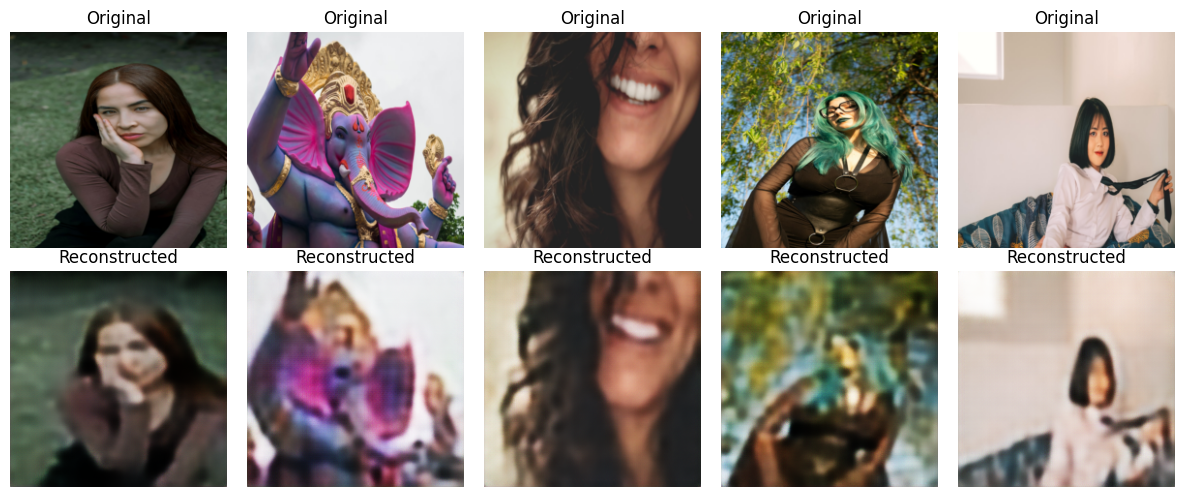

In [33]:
# model.eval()

# with torch.no_grad():
#     images, _ = next(iter(train_loader))
#     images = images.to(device)
#     outputs = model(images)

# images = images.cpu()
# outputs = outputs.cpu()

# fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# for i in range(5):
#     axes[0, i].imshow(images[i].permute(1, 2, 0).numpy())
#     axes[0, i].set_title("Original")
#     axes[0, i].axis("off")

#     axes[1, i].imshow(outputs[i].permute(1, 2, 0).numpy())
#     axes[1, i].set_title("Reconstructed")
#     axes[1, i].axis("off")

# plt.tight_layout()
# plt.show()

In [34]:
torch.save(model.state_dict(), "model_weights.pth")
torch.save(model, "full_model.pth")